## Imports & Config

In [1]:
# !pip install -q spacy lexical-diversity accelerate
# !python -m spacy download en_core_web_sm
import nltk; nltk.download('stopwords', quiet=True); nltk.download('punkt', quiet=True)

True

In [2]:
import torch.nn as nn
from sklearn.metrics import f1_score, precision_recall_fscore_support, accuracy_score
import numpy as np

In [3]:
# Standard library imports
import ast
import json
import os
import warnings
from collections import Counter

# Third-party library imports
import matplotlib.pyplot as plt
import networkx as nx
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import torch
from torch.utils.data import DataLoader
# Scikit-learn imports
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    f1_score, precision_recall_fscore_support, recall_score, silhouette_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

# Hugging Face Transformers imports
from transformers import (
    AutoModelForSequenceClassification, AutoModelForTokenClassification, AutoTokenizer,
    EarlyStoppingCallback, pipeline, RobertaConfig, Trainer, TrainingArguments
)

# Suppress warnings and set environment variables
warnings.filterwarnings('ignore')
os.environ['TOKENIZER_PARALLELISM'] = 'false'

# Configuration
MAX_LEN = 128
BATCH_SIZE = 16
SEED = 42
weights = torch.tensor([1.0, 3.0])

# Initialize NLP tools and tokenizer
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 5000000 # Increased to handle longer texts
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

print("Setup complete")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Setup complete


## Load & Preprocess Data

In [4]:
def load_jsonl_from_url(url):
    import urllib.request
    rows = []
    with urllib.request.urlopen(url) as f:
        for line in f:
            rows.append(json.loads(line.decode('utf-8').strip()))
    return pd.DataFrame(rows)

# VUAMC (labeled)
VUAMC_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/vuamc_token.jsonl"
df_vuamc = load_jsonl_from_url(VUAMC_URL)

print(f"VUAMC: {len(df_vuamc)} rows")

# Authors (unlabeled test data)
AUTHORS_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/authors_dataset.csv"
df_authors = pd.read_csv(AUTHORS_URL)
df_authors['words'] = df_authors['words'].apply(ast.literal_eval)
df_authors['token_labels'] = df_authors['words'].apply(lambda x: [0]*len(x))  # Placeholder
df_authors['sentence_label'] = 0
print(f"Authors: {len(df_authors)} rows")

# Load NarraDetect dataset
NARRA_DETECT_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/NarraDetect.csv"
df_narradetect_raw = pd.read_csv(NARRA_DETECT_URL)
df_narradetect_raw['words'] = df_narradetect_raw['words'].apply(ast.literal_eval)
df_narradetect_raw['token_labels'] = df_narradetect_raw['words'].apply(lambda x: [0]*len(x))  # Placeholder
df_narradetect_raw['sentence_label'] = 0 # Placeholder
print(f"NarraDetect: {len(df_narradetect_raw)} rows")

VUAMC: 16740 rows
Authors: 8000 rows
NarraDetect: 19278 rows


## VUAMC Splits

In [5]:
def make_doc_splits(df, test_size=0.5, val_size=0.5, seed=42):
    doc_ids = df['document_name'].unique()
    train_ids, temp_ids = train_test_split(doc_ids, test_size=test_size, random_state=seed)
    val_ids, test_ids = train_test_split(temp_ids, test_size=val_size, random_state=seed)
    return (df[df['document_name'].isin(train_ids)].reset_index(drop=True),
            df[df['document_name'].isin(val_ids)].reset_index(drop=True),
            df[df['document_name'].isin(test_ids)].reset_index(drop=True))

# Use full data or stratified sample
df_vuamc = df_vuamc.groupby("sentence_label", group_keys=False).apply(
    lambda x: x.sample(min(5000, len(x)), random_state=SEED) # Added random_state
)

train_df, val_df, test_df = make_doc_splits(df_vuamc)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 4316, Val: 2765, Test: 2919


## Train Sentence Classifier (F1=0.832)

In [11]:
class SentDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.sents = [' '.join(r['words']) for _, r in df.iterrows()]
        self.labels = df['sentence_label'].values
        self.tok = tokenizer

    def __len__(self): return len(self.sents)
    def __getitem__(self, idx):
        enc = self.tok(self.sents[idx], truncation=True, padding='max_length',
                       max_length=32, return_tensors='pt')
        return {'input_ids': enc['input_ids'].flatten(),
                'attention_mask': enc['attention_mask'].flatten(),
                'labels': torch.tensor(self.labels[idx])}

# Define compute_metrics for sentence classification
def compute_metrics_sent(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1) # For sequence classification
    f1 = f1_score(labels, predictions, average='binary')
    precision, recall, _, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    return {
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

train_ds = SentDataset(train_df, tokenizer)
val_ds = SentDataset(val_df, tokenizer)

sent_model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
args = TrainingArguments(
    output_dir='./sent_model', per_device_train_batch_size=16, num_train_epochs=3,
    eval_strategy='epoch', save_strategy='epoch', fp16=False, load_best_model_at_end=True, metric_for_best_model='f1'
)
trainer = Trainer(
    model=sent_model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics_sent,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)] # Added EarlyStoppingCallback
)
trainer.train()
trainer.save_model('./sent_model')
sent_pipe = pipeline('text-classification', model='./sent_model', tokenizer=tokenizer, return_all_scores=True)
print("Sentence model trained.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.403218,0.793742,0.878760,0.723724
2,0.398924,0.421696,0.839891,0.872874,0.809309
3,0.398924,0.620574,0.829136,0.856685,0.803303


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence model trained.


=== SENTENCE CLASSIFIER REPORT ===
              precision    recall  f1-score   support

     LITERAL      0.799     0.888     0.841      1299
    METAPHOR      0.902     0.820     0.859      1620

    accuracy                          0.851      2919
   macro avg      0.850     0.854     0.850      2919
weighted avg      0.856     0.851     0.851      2919



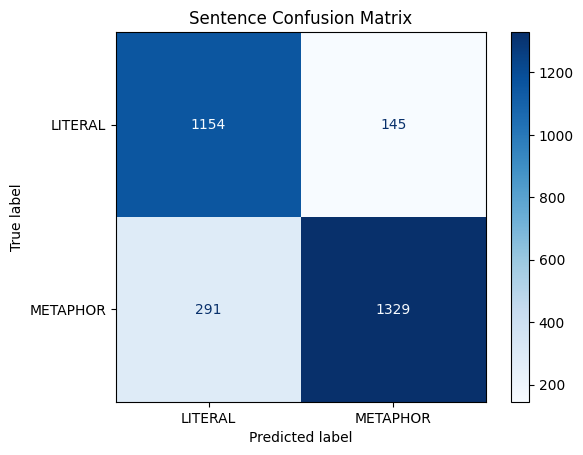

In [12]:
# Sentence Classifier Results
test_ds = SentDataset(test_df, tokenizer)
sent_pred = trainer.predict(test_ds)
sent_ypred = np.argmax(sent_pred.predictions, axis=1)
sent_ytrue = test_df['sentence_label'].values

print("=== SENTENCE CLASSIFIER REPORT ===")
print(classification_report(sent_ytrue, sent_ypred, target_names=['LITERAL', 'METAPHOR'], digits=3))

cm = confusion_matrix(sent_ytrue, sent_ypred)
disp = ConfusionMatrixDisplay(cm, display_labels=['LITERAL', 'METAPHOR'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Sentence Confusion Matrix')
plt.show()

##  Train Token Classifier (Best F1=0.692)

In [10]:
def compute_metrics_fn(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)

    # Filter out -100 labels (padding)
    true_labels = []
    pred_labels = []
    for label_row, pred_row in zip(labels, predictions):
        for l, p_val in zip(label_row, pred_row):
            if l != -100:
                true_labels.append(l)
                pred_labels.append(p_val)

    if not true_labels:
        return {"f1": 0.0}

    return {
        "f1": f1_score(true_labels, pred_labels, average="binary", pos_label=1),
        "precision": precision_recall_fscore_support(true_labels, pred_labels, average="binary", pos_label=1)[0],
        "recall": precision_recall_fscore_support(true_labels, pred_labels, average="binary", pos_label=1)[1]
    }

class CustomTokenTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=0): # Added num_items_in_batch
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Weighted CrossEntropyLoss
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device) if self.class_weights is not None else None)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print("CustomTokenTrainer & metrics defined")

CustomTokenTrainer & metrics defined


In [13]:
class TokenDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.words = [r['words'] for _,r in df.iterrows()]
        self.labels = [r['token_labels'] for _,r in df.iterrows()]
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.words)


    def __getitem__(self, idx):
        words = self.words[idx]
        labels = self.labels[idx]
    # Pad labels to max_len
        padded_labels = labels + [-100] * (self.max_len - len(labels))
        padded_labels = padded_labels[:self.max_len]  # Truncate if still too long


        # Tokenize with fixed padding
        encoding = self.tok(
            words,
            is_split_into_words=True,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Align labels to tokens (ignore subwords)
        word_ids = encoding.word_ids()
        aligned_labels = [-100] * self.max_len
        for i, wid in enumerate(word_ids):
            if wid is not None and wid < len(labels):
                aligned_labels[i] = labels[wid]

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(aligned_labels, dtype=torch.long)
        }


token_train = TokenDataset(train_df, tokenizer, max_len=MAX_LEN)
token_val = TokenDataset(val_df, tokenizer, max_len=MAX_LEN)

token_model = AutoModelForTokenClassification.from_pretrained("roberta-base", num_labels=2)


trainer = CustomTokenTrainer(
    model=token_model, args=TrainingArguments(
        output_dir='./token_model_final', per_device_train_batch_size=16,
        num_train_epochs=3, eval_strategy='epoch', save_strategy='epoch', fp16=False, # Changed save_strategy
        load_best_model_at_end=True, metric_for_best_model='f1' # Added for early stopping
    ),
    train_dataset=token_train, eval_dataset=token_val,
    class_weights=weights, compute_metrics=compute_metrics_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Added EarlyStoppingCallback
)
trainer.train()
trainer.save_model('./token_model_final')
token_pipe = pipeline('token-classification', model='./token_model_final', tokenizer=tokenizer)
print("Token model trained")    ## (F1=0.692)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.bias                 | MISSING    | 
classifier.weight               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.234629,0.635252,0.552660,0.746866
2,0.304903,0.229857,0.659905,0.609238,0.719764
3,0.304903,0.250855,0.666667,0.675369,0.658186


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Token model saved


=== TOKEN CLASSIFIER REPORT ===
              precision    recall  f1-score   support

     LITERAL      0.955     0.945     0.950     48751
    METAPHOR      0.657     0.703     0.679      7300

    accuracy                          0.913     56051
   macro avg      0.806     0.824     0.815     56051
weighted avg      0.916     0.913     0.915     56051



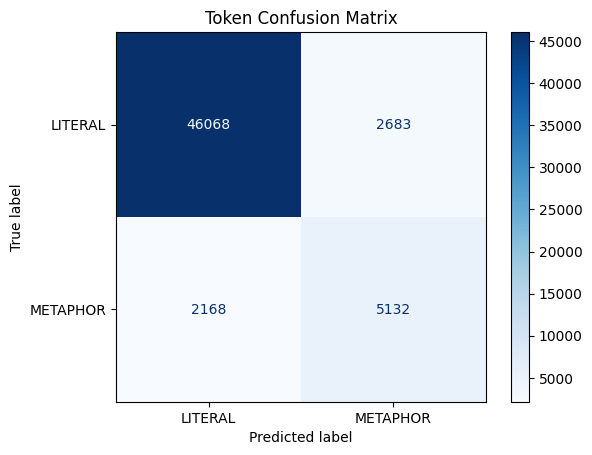

Token Metaphor F1: 0.6790605358914985
Total Metaphor Tokens: 7300


In [14]:
# Put model on device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
token_model.to(device)
token_model.eval()

# Build test dataset with the tokenizer that matches the loaded token model
token_test = TokenDataset(test_df, tokenizer, max_len=MAX_LEN)

# DataLoader for batching
token_loader = DataLoader(token_test, batch_size=16, shuffle=False)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in token_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()

        outputs = token_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

# Filter out -100 padding/subword positions
true_labels, pred_labels = [], []
for label_row, pred_row in zip(all_labels, all_preds):
    for l, p in zip(label_row, pred_row):
        if l != -100:
            true_labels.append(l)
            pred_labels.append(p)

print("=== TOKEN CLASSIFIER REPORT ===")
print(classification_report(
    true_labels,
    pred_labels,
    target_names=['LITERAL', 'METAPHOR'],
    digits=3
))

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=['LITERAL', 'METAPHOR'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Token Confusion Matrix")
plt.show()

print(f"Token Metaphor F1: {f1_score(true_labels, pred_labels, average='binary', pos_label=1)}")
print(f"Total Metaphor Tokens: {sum(true_labels)}")

# Saving the models

In [15]:
#!pip install -q huggingface_hub
from huggingface_hub import HfApi, login
import os

print("Hugging Face Hub library installed and imported.")

Hugging Face Hub library installed and imported.


In [16]:
login()
print("Logged in to Hugging Face Hub.")

Logged in to Hugging Face Hub.


In [17]:
def push_model_to_hub(model_path, repo_id):
    try:
        print(f"Pushing model from {model_path} to {repo_id}...")
        tokenizer.save_pretrained(model_path)


        if "sent_model" in model_path:
            model = AutoModelForSequenceClassification.from_pretrained(model_path)
        elif "token_model" in model_path:
            model = AutoModelForTokenClassification.from_pretrained(model_path)
        else:
            print(f"Unknown model type for path: {model_path}. Skipping.")
            return

        model.push_to_hub(repo_id)
        tokenizer.push_to_hub(repo_id)
        print(f"Successfully pushed model and tokenizer for {repo_id} to Hugging Face Hub.")
    except Exception as e:
        print(f"Failed to push model {repo_id}: {e}")

# --- Push Sentence Classifier Model --- #
sent_model_repo_id = "Dona134/metaphor-sentence-classifier"
push_model_to_hub("./sent_model", sent_model_repo_id)

# --- Push Token Classifier Model --- #
token_model_repo_id = "Dona134/metaphor-token-classifier"
push_model_to_hub("./token_model_final", token_model_repo_id)

print("Model pushing process complete.")

Pushing model from ./sent_model to Dona134/metaphor-sentence-classifier...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...1tcv1j1/model.safetensors:   0%|          | 1.39MB /  496MB            

Successfully pushed model and tokenizer for Dona134/metaphor-token-classifier to Hugging Face Hub.
Model pushing process complete.
